# Kaggle — Train the Multiclass Transient Classifier

End-to-end workflow for running `scripts/train_multiclass_experiment.py` on
Kaggle with data loaded from a Kaggle dataset.

**Before you start:**

1. Add your dataset `astronomical_transient` via **Add Input** on the right panel.
2. Set **Session options → Accelerator → GPU T4 x2**.
3. Run the cells top to bottom.

**What the pipeline produces** (per run, under `results/experiments/<run_name>/`):

- `summary.json` — top-line test metrics + config
- `full_eval.json` — per-class precision/recall/F1 + confusion matrix
- `confusion_matrix.png` / `confusion_matrix_raw.png`
- `training_curves.png`

## 1. Sanity-check the runtime

You need a GPU. If `nvidia-smi` errors, go back to **Runtime → Change runtime type**.

In [1]:
!nvidia-smi
import sys, torch
print('Python   :', sys.version.split()[0])
print('Torch    :', torch.__version__)
print('CUDA     :', torch.version.cuda)
print('GPU avail:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name :', torch.cuda.get_device_name(0))

Mon Apr 27 19:37:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. (Kaggle — skip this cell)

Google Drive mount is not needed on Kaggle. Your dataset is already available
under `/kaggle/input/`. Proceed to cell 3.

In [ ]:
# Kaggle: no Drive mount needed — data comes from /kaggle/input/
print("Skipping Drive mount — running on Kaggle")

## 3. Clone the repo

If the clone URL below is private you'll need a GitHub Personal Access Token — in that
case replace the URL with `https://<TOKEN>@github.com/lakhia13/transient-astronomy.git`.
Public repos work with the plain URL.

In [4]:
%cd /kaggle/working
!rm -rf transient-astronomy
!git clone https://github.com/lakhia13/transient-astronomy.git
%cd transient-astronomy
!git checkout Nishant/multiclass
!git lfs install
!git lfs pull
!ls -lh checkpoints/ || true

/kaggle/working
Cloning into 'transient-astronomy'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 104 (delta 20), reused 92 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 3.99 MiB | 21.61 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/kaggle/working/transient-astronomy
Branch 'Nishant/multiclass' set up to track remote branch 'Nishant/multiclass' from 'origin'.
Switched to a new branch 'Nishant/multiclass'
Updated git hooks.
Git LFS initialized.
total 128Mg LFS objects: 100% (1/1), 134 MB | 13 MB/s                           
drwxr-xr-x 2 root root 4.0K Apr 28 01:31 experiments
-rw-r--r-- 1 root root 128M Apr 28 01:31 resnet18_rb_best.pt
-rw-r--r-- 1 root root 5.0K Apr 28 01:31 resnet18_rb_history.json


In [5]:
!grep num_workers configs/multiclass_exp_v1.yaml   

  num_workers: 2


## 4. Install dependencies

We install deps directly via `pip` (skipping `uv` + `pyproject.toml`, which insists on
Python 3.12 and Colab ships 3.11). `torch` is preinstalled, so we only add what's missing.

In [5]:
%pip install -q \
    timm \
    albumentations \
    astropy \
    pyyaml \
    scikit-learn \
    pandas \
    matplotlib \
    seaborn \
    tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# (debug cell removed)

## 5. Copy the dataset into the repo

The training script expects data at `data/` relative to the repo root.
On Kaggle, input datasets are read-only under `/kaggle/input/`,
so we copy them into the working repo directory.

In [7]:
import os
os.makedirs('data', exist_ok=True)

# Copy from Kaggle input into the repo working directory
!cp -r /kaggle/input/datasets/nishantgc/astronomical-transient/data/. data/

!echo "--- top level of data/ ---"
!ls data/
!echo "--- data/processed/ ---"
!ls data/processed/ | head -20

--- top level of data/ ---
labels.csv  processed  raw
--- data/processed/ ---
split_labels.csv
stats.json
test
train
val


In [ ]:
# (debug cell removed)

In [ ]:
# (debug cell removed)

In [9]:
# Fix nested data/data layouts if that's what your zip produced.
import shutil
from pathlib import Path

nested = Path('data/data')
if nested.exists():
    print(f'Found nested {nested}, flattening...')
    for item in nested.iterdir():
        target = Path('data') / item.name
        if target.exists():
            print(f'  skip {item.name} (already exists at target)')
            continue
        shutil.move(str(item), str(target))
    nested.rmdir()
    print('Done.')
else:
    print('No nested data/data — layout is already correct.')

!ls data/
!ls data/processed/ 2>/dev/null | head

No nested data/data — layout is already correct.
labels.csv  processed  raw
split_labels.csv
stats.json
test
train
val


In [10]:
# Verify the pipeline will find what it needs.
from pathlib import Path
import pandas as pd

labels_csv = Path('data/labels.csv')
processed_dir = Path('data/processed')

assert labels_csv.exists(), f'Missing: {labels_csv}'
assert (processed_dir / 'train').exists(), f'Missing: {processed_dir}/train'
assert (processed_dir / 'val').exists(),   f'Missing: {processed_dir}/val'
assert (processed_dir / 'test').exists(),  f'Missing: {processed_dir}/test'

df = pd.read_csv(labels_csv)
print(f'labels.csv rows : {len(df):,}')
print(f'Class counts    :\n{df["class"].value_counts()}')
for split in ('train', 'val', 'test'):
    n = len(list((processed_dir / split).glob('*.npy')))
    print(f'{split:>5} .npy files: {n:,}')

labels.csv rows : 131,270
Class counts    :
class
AGN         55858
VS          29096
SN          28046
bogus       15677
asteroid     2593
Name: count, dtype: int64
train .npy files: 86,661
  val .npy files: 18,153
 test .npy files: 18,011


## 6. Smoke test (1 epoch)

Always run this before a full training pass. It writes to a disposable
`<run_name>_smoke` directory so a failure or Ctrl+C doesn't pollute your real results.
If this finishes cleanly in a few minutes with non-NaN metrics, the pipeline works.

In [6]:
!python scripts/train_multiclass_experiment.py \
    --config configs/multiclass_exp_v1.yaml \
    --smoke-test

NumExpr defaulting to 4 threads.
Traceback (most recent call last):
  File "/kaggle/working/transient-astronomy/scripts/train_multiclass_experiment.py", line 366, in <module>
    main()
  File "/kaggle/working/transient-astronomy/scripts/train_multiclass_experiment.py", line 154, in main
    raise FileNotFoundError(
FileNotFoundError: labels_csv not found: /kaggle/working/transient-astronomy/data/labels.csv
Generate data first (download + preprocess) or point config paths to an existing dataset location.


In [11]:
# Check where you actually are and if the repo exists
!pwd
!ls /kaggle/working/
!find /kaggle/working -name "train_multiclass_experiment.py" 2>/dev/null

/kaggle/working/transient-astronomy
transient-astronomy
/kaggle/working/transient-astronomy/scripts/train_multiclass_experiment.py


## 7. Full training run

Uses the `epochs`, `loss`, `batch_size`, etc. from
`configs/multiclass_exp_v1.yaml`. Expect **~45–90 minutes** on a T4 for 30 epochs.
The process writes a per-epoch `*_history.json` as it goes, so if Colab disconnects you
still have partial logs. The best checkpoint is saved every time validation improves.

In [14]:
!python scripts/train_multiclass_experiment.py --config configs/multiclass_exp_v1.yaml --overwrite
                                                        

NumExpr defaulting to 4 threads.
[setup] run_name=resnet18_mc_nishant_v1 | device=cuda | seed=42
Time split: train=91889  val=19690  test=19691  (MJD 58270.4 – 60635.1 / 60635.1 – 60918.3 / 60918.3 – 61128.3)
Datasets built — train: 91889  val: 19690  test: 19691
[data] train=91889 val=19690 test=19691
/kaggle/working/transient-astronomy/src/train.py:289: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Training resnet18_mc_nishant_v1 | device=cuda | epochs=30 | lr=0.001 | loss=CrossEntropyLoss
/kaggle/working/transient-astronomy/src/train.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/kaggle/working/transient-astronomy/src/train.py:187: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch  

In [ ]:
import json                                                     
from pathlib import Path                                  
                                                                  
history_path = Path('checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_history.json')
if history_path.exists():                                       
    history = json.loads(history_path.read_text())        
    print(f"Epochs completed so far: {len(history)}")           
    for e in history[-3:]:
        print(e)                                                
else:                                                     
    print("No history file yet — still on epoch 1")             

In [ ]:
from IPython.display import FileLink                                                                                                                                                   
  FileLink('transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt')     

In [17]:
import shutil
shutil.copy(
      '/kaggle/working/transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt',
      '/kaggle/working/resnet18_mc_nishant_v1_best.pt'
)

shutil.copytree(
      '/kaggle/working/transient-astronomy/results/experiments/resnet18_mc_nishant_v1',
      '/kaggle/working/results_resnet18_mc_nishant_v1',
      dirs_exist_ok=True
)

print("Done! Download from Output panel.")

Done! Download from Output panel.


In [21]:
from IPython.display import FileLink                                                                                                                                                   
display(FileLink('transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt'))                                                                 

/kaggle/working/transient-astronomy/transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt

In [22]:
import shutil
import os
from IPython.display import FileLink

# Define paths based on your logs
checkpoint_dir = '/kaggle/working/transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1'
zip_name = 'resnet18_nishant_final'

# Create the zip
shutil.make_archive(zip_name, 'zip', checkpoint_dir)

# Generate a direct download link
FileLink(f'{zip_name}.zip')

/kaggle/working/transient-astronomy/resnet18_nishant_final.zip

In [23]:
import os

# Search for any .pt files in the working directory
found_files = []
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.endswith(".pt"):
            full_path = os.path.join(root, file)
            found_files.append(full_path)
            print(f"FOUND: {full_path}")

if not found_files:
    print("Zero .pt files found. Checking if they were saved outside /kaggle/working...")

FOUND: /kaggle/working/resnet18_mc_nishant_v1_best.pt
FOUND: /kaggle/working/transient-astronomy/checkpoints/resnet18_rb_best.pt
FOUND: /kaggle/working/transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt


In [24]:
from IPython.display import FileLink
import os

# This is the file the search found at your root
target_file = '/kaggle/working/resnet18_mc_nishant_v1_best.pt'

if os.path.exists(target_file):
    print("File confirmed. Click the link below to download:")
    display(FileLink('resnet18_mc_nishant_v1_best.pt'))
else:
    print("File not found at root. Checking the experimental folder...")
    # Fallback to the deep directory if the root one was a ghost
    fallback = '/kaggle/working/transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt'
    import shutil
    shutil.copy(fallback, '/kaggle/working/final_model_download.pt')
    display(FileLink('final_model_download.pt'))

File confirmed. Click the link below to download:


/kaggle/working/transient-astronomy/resnet18_mc_nishant_v1_best.pt

In [25]:
from IPython.display import FileLink                                                                                                                                                   
display(FileLink('resnet18_mc_nishant_v1_best.pt'))                                                                                                                                    

/kaggle/working/transient-astronomy/resnet18_mc_nishant_v1_best.pt

In [26]:
                                                                                                                                                                                         
  import shutil                                                                                                                                                                        
  from IPython.display import FileLink                                                                                                                                                   
                                                                                                                                                                                         
  shutil.copy(
      '/kaggle/working/transient-astronomy/checkpoints/experiments/resnet18_mc_nishant_v1/resnet18_mc_nishant_v1_best.pt',                                                               
      '/kaggle/working/resnet18_mc_nishant_v1_best.pt'                                                                                                                                   
  )                                                                                                                                                                                      
                                                            
  import os                                                                                                                                                                              
  print(os.path.exists('/kaggle/working/resnet18_mc_nishant_v1_best.pt'))
  display(FileLink('resnet18_mc_nishant_v1_best.pt'))                                                                                                                                    

True


/kaggle/working/transient-astronomy/resnet18_mc_nishant_v1_best.pt

## 8. Inspect the results

In [28]:
import json
from pathlib import Path
from IPython.display import Image, display

import yaml
cfg = yaml.safe_load(open('configs/multiclass_exp_v1.yaml'))
run_name = cfg['experiment']['name']
results_dir = Path('results/experiments') / run_name

summary = json.loads((results_dir / 'summary.json').read_text())
print(f'Run           : {summary["run_name"]}')
print(f'Best epoch    : {summary["train"]["best_epoch"]}')
print(f'Best val acc  : {summary["train"]["best_val_metric"]:.4f}')
print(f'Test accuracy : {summary["test"]["accuracy"]:.4f}')
print(f'Test macro-F1 : {summary["test"]["macro_f1"]:.4f}')
print(f'Test weighted-F1: {summary["test"]["weighted_f1"]:.4f}')
print()
print('Per-class metrics:')
for cls, m in summary['test']['per_class_metrics'].items():
    print(f'  {cls:>8} | precision={m["precision"]:.3f} | recall={m["recall"]:.3f} '
          f'| F1={m["f1"]:.3f} | n={m["support"]}')

Run           : resnet18_mc_nishant_v1
Best epoch    : 30
Best val acc  : 0.8868
Test accuracy : 0.7839
Test macro-F1 : 0.6552
Test weighted-F1: 0.7503

Per-class metrics:
     bogus | precision=0.705 | recall=0.961 | F1=0.814 | n=3381
        SN | precision=0.420 | recall=0.818 | F1=0.555 | n=2050
       AGN | precision=0.955 | recall=0.860 | F1=0.905 | n=7603
        VS | precision=0.941 | recall=0.957 | F1=0.949 | n=4073
  asteroid | precision=0.657 | recall=0.027 | F1=0.053 | n=2584


training_curves.png


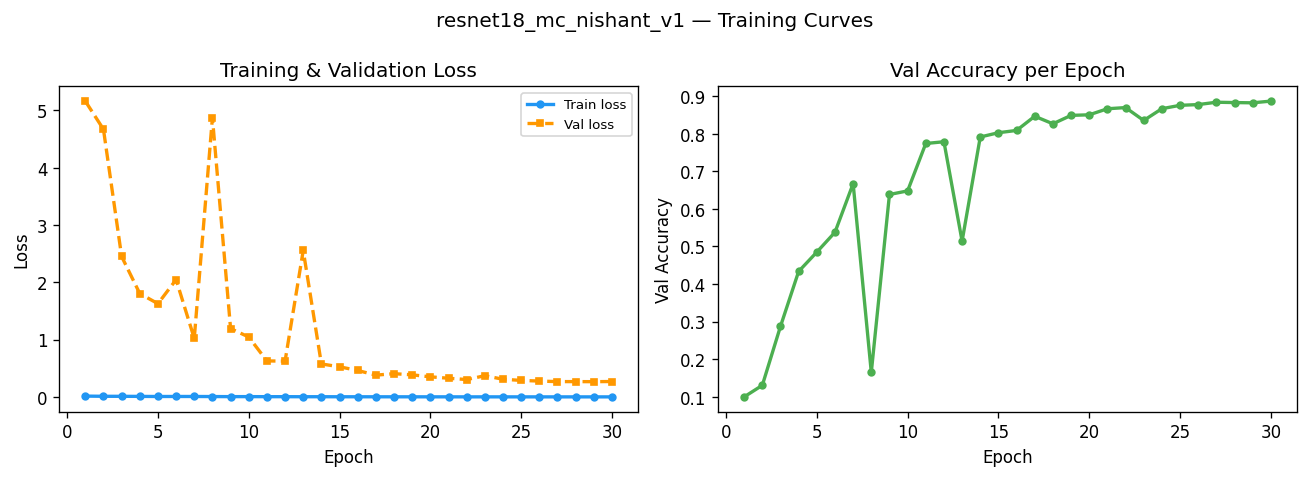

confusion_matrix.png


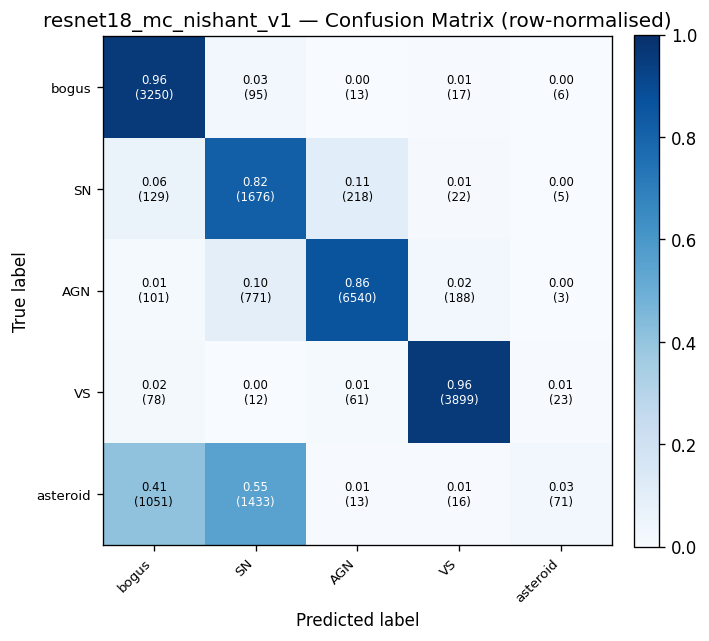

confusion_matrix_raw.png


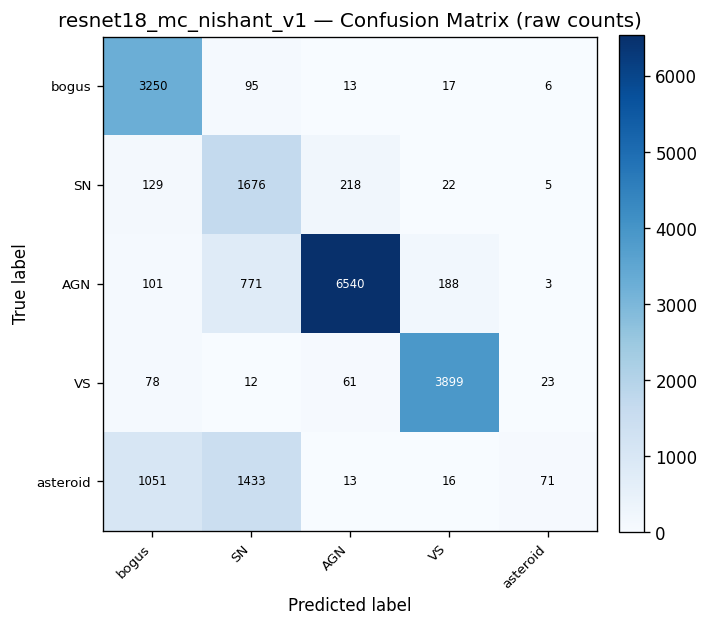

In [29]:
for fname in ('training_curves.png', 'confusion_matrix.png', 'confusion_matrix_raw.png'):
    p = results_dir / fname
    if p.exists():
        print(fname)
        display(Image(str(p)))
    else:
        print(f'(missing: {p})')

## 9. Save outputs to Kaggle working directory

Kaggle persists `/kaggle/working` — your results will be available
as notebook output files after the session ends. You can also download
them directly from the Output panel on the right.

In [30]:
import yaml, shutil
from pathlib import Path

cfg = yaml.safe_load(open('configs/multiclass_exp_v1.yaml'))
run_name = cfg['experiment']['name']

out_dir = Path('/kaggle/working') / run_name
out_dir.mkdir(parents=True, exist_ok=True)

shutil.copytree(f'checkpoints/experiments/{run_name}', str(out_dir / 'checkpoints'), dirs_exist_ok=True)
shutil.copytree(f'results/experiments/{run_name}',     str(out_dir / 'results'),     dirs_exist_ok=True)

print(f'Saved to /kaggle/working/{run_name}/')
!ls /kaggle/working/{run_name}/

Saved to /kaggle/working/resnet18_mc_nishant_v1/
checkpoints  results


## 10. (Optional) Commit the checkpoint back to GitHub via Git LFS

Easier to do this on your laptop: download
`runs/<run_name>/<run_name>_best.pt` from Drive, drop it into
`checkpoints/experiments/<run_name>/` locally, then:

```bash
brew install git-lfs     # one-time
git lfs install          # one-time
git lfs track 'checkpoints/experiments/**/*.pt'   # already covered by *.pt rule if set
git add .gitattributes checkpoints/experiments/<run_name>/
git add results/experiments/<run_name>/
git commit -m 'Add multiclass run <run_name>'
git push
```

LFS handles the large `.pt` file transparently. The JSON/PNG result files go through
normal git.